# Top-k overlap sweep across domains (2026-04-12)

Pick one SAE firing-rate distribution per domain (biology / chemistry / math / physics), all at layer 31, width 16k, canonical SAE, padding tokens NOT included in the firing-rate calc. Sweep `k` log-spaced, compute `|topk(A) ∩ topk(B)| / k`, and reduce each pair to a single similarity via trapezoidal AUC on normalized x = k/N (anchored at (0, 0)).

Outputs saved next to this notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from sae_scoping.data_science import (
    default_ks,
    load_distribution,
    overlap_curve_auc,
    pairwise_overlap_auc_matrix,
    top_k_overlap_curve,
)

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
NOTEBOOK_DIR = REPO_ROOT / "experiments" / "sae_scoping" / "top_k_intersection_sweep_2026_04_12"
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)
CURVES_PLOT = NOTEBOOK_DIR / "overlap_curves.png"
HEATMAP_PLOT = NOTEBOOK_DIR / "auc_similarity_heatmap.png"
print("Plots will be saved to:")
print("  ", CURVES_PLOT)
print("  ", HEATMAP_PLOT)

Plots will be saved to:
   /Users/4gate/git/SAEScoping/experiments/sae_scoping/top_k_intersection_sweep_2026_04_12/overlap_curves.png
   /Users/4gate/git/SAEScoping/experiments/sae_scoping/top_k_intersection_sweep_2026_04_12/auc_similarity_heatmap.png


## One distribution per domain

- **biology** — canonical path used across the Dec-2025 experiment scripts (`script_2025_12_16_vibecheck_ultrachat.ipynb`, `script_2025_12_12_judging_checkpoints_do_generation.py`). Local copy under `downloaded/`.
- **chemistry / math / physics** — from the March-2026 `distributions_cache/` folder (same experiment root).

In [2]:
BIO_ROOT = REPO_ROOT / "experiments" / "sae_scoping" / "biology_pruning_3e-4_2026_03_30"
DIST_PATHS = {
    "biology": BIO_ROOT
    / "downloaded/deleteme_cache_bio_only/ignore_padding_True/biology"
    / "layer_31--width_16k--canonical/distribution.safetensors",
    "chemistry": BIO_ROOT
    / "distributions_cache/ignore_padding_True/chemistry"
    / "layer_31--width_16k--canonical/distribution.safetensors",
    "math": BIO_ROOT
    / "distributions_cache/ignore_padding_True/math"
    / "layer_31--width_16k--canonical/distribution.safetensors",
    "physics": BIO_ROOT
    / "distributions_cache/ignore_padding_True/physics"
    / "layer_31--width_16k--canonical/distribution.safetensors",
}
for name, p in DIST_PATHS.items():
    assert p.exists(), f"missing: {p}"
dists = {name: load_distribution(p) for name, p in DIST_PATHS.items()}
widths = {name: d.numel() for name, d in dists.items()}
assert len(set(widths.values())) == 1, f"widths differ: {widths}"
N = next(iter(widths.values()))
print(f"Loaded {len(dists)} distributions, width N = {N}")

Loaded 4 distributions, width N = 16384


## Per-pair overlap curves

Saved: /Users/4gate/git/SAEScoping/experiments/sae_scoping/top_k_intersection_sweep_2026_04_12/overlap_curves.png


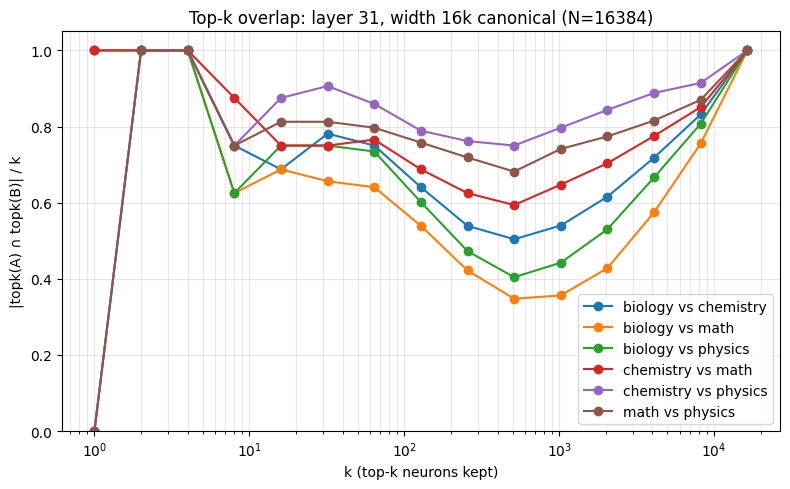

In [3]:
from itertools import combinations

ks = default_ks(N)
curves: dict[tuple[str, str], torch.Tensor] = {}
for a, b in combinations(sorted(dists), 2):
    curves[(a, b)] = top_k_overlap_curve(dists[a], dists[b], ks=ks)

fig, ax = plt.subplots(figsize=(8, 5))
ks_list = ks.tolist()
for (a, b), curve in curves.items():
    ax.plot(ks_list, curve.tolist(), marker="o", label=f"{a} vs {b}")
ax.set_xscale("log")
ax.set_xlabel("k (top-k neurons kept)")
ax.set_ylabel("|topk(A) \u2229 topk(B)| / k")
ax.set_ylim(0, 1.05)
ax.set_title(f"Top-k overlap: layer 31, width 16k canonical (N={N})")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(CURVES_PLOT, dpi=150)
print("Saved:", CURVES_PLOT)
plt.show()

## AUC similarity heatmap

Reduce each overlap curve to a single similarity via trapezoidal AUC on the normalized x-axis k/N, anchored at (0, 0). Higher = more similar.

Similarity matrix:
  biology    [1.0, 0.80596923828125, 0.71807861328125, 0.771026611328125]
  chemistry  [0.80596923828125, 1.0, 0.8406219482421875, 0.9120635986328125]
  math       [0.71807861328125, 0.8406219482421875, 1.0, 0.8699951171875]
  physics    [0.771026611328125, 0.9120635986328125, 0.8699951171875, 1.0]
Saved: /Users/4gate/git/SAEScoping/experiments/sae_scoping/top_k_intersection_sweep_2026_04_12/auc_similarity_heatmap.png


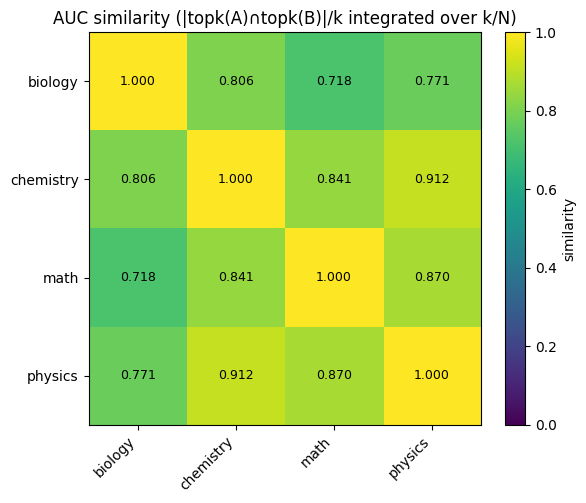

In [4]:
sorted_dists = {name: dists[name] for name in sorted(dists)}
names, matrix = pairwise_overlap_auc_matrix(sorted_dists, ks=ks)
print("Similarity matrix:")
for i, n in enumerate(names):
    print(f"  {n:10s}", matrix[i].tolist())

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matrix.numpy(), vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(len(names)))
ax.set_yticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticklabels(names)
ax.set_title("AUC similarity (|topk(A)\u2229topk(B)|/k integrated over k/N)")
for i in range(len(names)):
    for j in range(len(names)):
        val = matrix[i, j].item()
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                color="white" if val < 0.5 else "black", fontsize=9)
fig.colorbar(im, ax=ax, label="similarity")
fig.tight_layout()
fig.savefig(HEATMAP_PLOT, dpi=150)
print("Saved:", HEATMAP_PLOT)
plt.show()

## Dense linear sweep: k = 100, 200, ..., 4000

Same four distributions, but a denser uniformly-spaced sweep over mid-range k.
The log-spaced default above jumps past this region (512 → 1024 → 2048 → 4096),
so we want finer resolution here to see how quickly overlap decays as we
prune below the top-4000 neurons.

Saved: /Users/4gate/git/SAEScoping/experiments/sae_scoping/top_k_intersection_sweep_2026_04_12/overlap_curves_dense_k100_4000.png

Overlap at selected k:
  pair                   k=100    k=500    k=1000   k=2000   k=4000 
  biology vs chemistry   0.690    0.508    0.540    0.609    0.716
  biology vs math        0.620    0.350    0.353    0.422    0.568
  biology vs physics     0.660    0.408    0.439    0.523    0.661
  chemistry vs math      0.730    0.590    0.641    0.706    0.772
  chemistry vs physics   0.810    0.752    0.798    0.845    0.888
  math vs physics        0.760    0.676    0.736    0.774    0.812


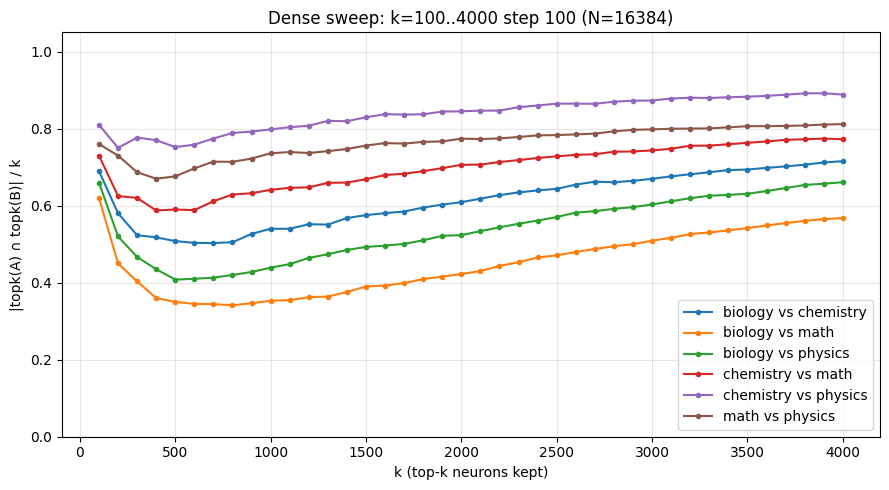

In [5]:
DENSE_KS = list(range(100, 4001, 100))  # [100, 200, ..., 4000]
DENSE_PLOT = NOTEBOOK_DIR / "overlap_curves_dense_k100_4000.png"

dense_curves: dict[tuple[str, str], torch.Tensor] = {}
for a, b in combinations(sorted(dists), 2):
    dense_curves[(a, b)] = top_k_overlap_curve(dists[a], dists[b], ks=DENSE_KS)

fig, ax = plt.subplots(figsize=(9, 5))
for (a, b), curve in dense_curves.items():
    ax.plot(DENSE_KS, curve.tolist(), marker=".", label=f"{a} vs {b}")
ax.set_xlabel("k (top-k neurons kept)")
ax.set_ylabel("|topk(A) \u2229 topk(B)| / k")
ax.set_ylim(0, 1.05)
ax.set_title(f"Dense sweep: k=100..4000 step 100 (N={N})")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(DENSE_PLOT, dpi=150)
print("Saved:", DENSE_PLOT)

# Also print a compact summary: overlap at a few reference k values.
print("\nOverlap at selected k:")
print(f"  {'pair':22s} " + "  ".join(f"k={k:<5d}" for k in [100, 500, 1000, 2000, 4000]))
for (a, b), curve in dense_curves.items():
    row = []
    for k in [100, 500, 1000, 2000, 4000]:
        idx = DENSE_KS.index(k)
        row.append(f"{curve[idx].item():.3f}")
    print(f"  {a+' vs '+b:22s} " + "    ".join(row))

plt.show()